# Caricamento dataset e esplorazione informativa



In [1]:
import pandas as pd

X_train = pd.read_csv("train.csv")
X_test = pd.read_csv("test.csv")


print(X_train.shape)
print(X_train.info())
print(X_test.info())
print(X_train.isna().mean() * 100)
print(X_test.isna().mean() * 100)

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64 

Effettuiamo l'imputazione delle features 'Age' e 'Embarked' per X_train e 'Age' e 'Fare' per X_test, mentre rimuoviamo la feature 'Cabin' poiché troppo sparsa

In [2]:
y_train = X_train["Survived"]

# Rimozioni variabili inutili
X_train = X_train.drop(columns=["Cabin", "Survived", "Ticket", "Name", "PassengerId"])
X_test = X_test.drop(columns=["Cabin", "Ticket", "Name", "PassengerId"])

# Effettuiamo un'imputazione per Age tramite group_by

# Per X_train facciamo transform sul train set
# transform restituisce una Series con le stesse dimensioni e indice della X_train
train_age_medians = X_train.groupby(['Pclass','Sex'])['Age'].transform('median') # Divide X_train nelle combinazioni possibili
X_train['Age'] = X_train['Age'].fillna(train_age_medians)

# Poiché sul test_set non possiamo fare transform, sennò sarebbe Data Leakage, 
# le mediane devono essere estratte dal training set

# Estraiamo la tabella di lookup dal train_set
median_map = X_train.groupby(['Pclass', 'Sex'])['Age'].median()


# Applichiamo la mappa alle righe di X_test, leggiamo la sua (Pclass,Sex) per ogni riga 
# e prendiamo il valore corrispondente dalla mappa  
test_age_imputed = X_test.set_index(['Pclass','Sex']).index.map(median_map)

# Riempiamo i valori mancanti 
X_test['Age'] = X_test['Age'].fillna(pd.Series(test_age_imputed, index=X_test.index))

In [3]:
print(median_map)
print(test_age_imputed)

print(X_test['Age'].isna().sum())
print(X_train['Age'].isna().sum())

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64
Index([25.0, 21.5, 30.0, 25.0, 21.5, 25.0, 21.5, 30.0, 21.5, 25.0,
       ...
       21.5, 21.5, 21.5, 35.0, 21.5, 25.0, 35.0, 25.0, 25.0, 25.0],
      dtype='float64', length=418)
0
0


Abbiamo imputato i dati per quanto riguarda la classe Age, i restanti verranno gestiti all'interno della Pipeline 

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

cat_features = X_train.select_dtypes(include=['bool', 'object', 'string']).columns
num_features = X_train.select_dtypes(include=['number']).columns

cat_pipeline = Pipeline(steps=[
    ("imp", SimpleImputer(strategy='most_frequent')),
    ("enc", OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", cat_pipeline, cat_features),
    ("num", num_pipeline, num_features)
])

preprocessor.set_output(transform="pandas")

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [5]:
import numpy as np

corr = X_train_processed.corr()
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
print(upper[abs(upper) > 0.80].stack())

# Nessuna features multicollineare

Series([], dtype: float64)


In [6]:
# Feature selection con un metodo embedded

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

# Classificatore binario con regolarizzazione L1 (solver 'liblinear')

clf_l1 = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
selector = SelectFromModel(estimator=clf_l1)

selector.fit(X_train_processed, y_train)
selected_features = selector.get_feature_names_out()
selector.set_output(transform='pandas')

X_train_sel = selector.transform(X_train_processed)
X_test_sel = selector.transform(X_test_processed)

print(f"Features selezionate: {selected_features}")
print("Nuova shape:", X_train_sel.shape)

Features selezionate: ['cat__Sex_male' 'cat__Embarked_S' 'num__Pclass' 'num__Age' 'num__SibSp'
 'num__Parch' 'num__Fare']
Nuova shape: (891, 7)


In [10]:
# Classificazione binaria con modello ensemble

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score


param_grid= {
    "n_estimators" : [50,100,150],
    "criterion" : ["gini", "entropy"],
    "min_samples_split" : [2,5,10]
}

cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=42)
rfc = RandomForestClassifier(random_state=42)

grid_rfc = GridSearchCV(estimator=rfc,param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)

grid_rfc.fit(X_train_sel, y_train)

best_estimator = grid_rfc.best_estimator_
best_params = grid_rfc.best_params_

rfc_train_pred = best_estimator.predict(X_train_sel)
rfc_train_prob = best_estimator.predict_proba(X_train_sel)

rfc_acc = accuracy_score(y_train,rfc_train_pred)
rfc_auc = roc_auc_score(y_train,rfc_train_prob[:,1])

print("Best estimator: {best_estimator}")
print(f"Best params: {best_params}")

print(f"Accuracy Train RFC : {rfc_acc:.2f}")
print(f"AUC score RFC in Train: {rfc_auc:.2f}")

Best estimator: {best_estimator}
Best params: {'criterion': 'gini', 'min_samples_split': 10, 'n_estimators': 50}
Accuracy Train RFC : 0.91
AUC score RFC in Train: 0.97



================ Test Config 1: {'filters': 16, 'kernel_size': 2, 'lr': 0.01} ================


Epoch    1: 100%|██████████| 12/12 [00:00<00:00, 255.33it/s]


Train loss: 0.6820
Validation loss: 0.6656
Test loss: 0.6656 Accuracy:   0.62
Metrics:



Epoch    2: 100%|██████████| 12/12 [00:00<00:00, 307.70it/s]


Train loss: 0.6478
Validation loss: 0.6655
Test loss: 0.6655 Accuracy:   0.62
Metrics:



...

Epoch   32: 100%|██████████| 12/12 [00:00<00:00, 324.34it/s]


Train loss: 0.4520
Validation loss: 0.5413
Test loss: 0.5413 Accuracy:   0.77
Metrics:



Epoch   33: 100%|██████████| 12/12 [00:00<00:00, 315.80it/s]


Train loss: 0.4436
Validation loss: 0.5429
Test loss: 0.5429 Accuracy:   0.75
Metrics:

--> Config 4 Risultati: Accuracy = 0.7537 | ROC-AUC = 0.8143

MIGLIOR CONFIGURAZIONE CNN:
{'filters': 64, 'kernel_size': 3, 'lr': 0.0005}
Accuracy (Validation): 0.7537
ROC-AUC  (Validation): 0.8143


ValueError: x, y, and format string must not be None

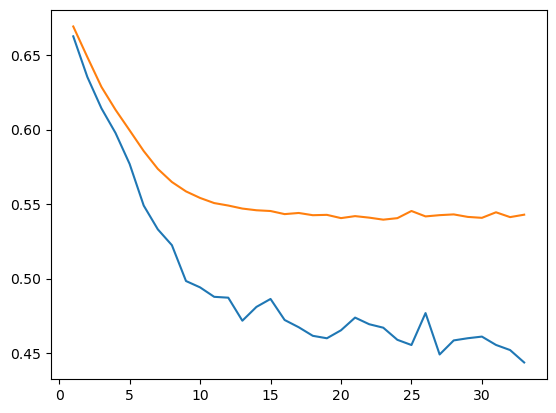

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import torchnn as tnn

# 1. Split di validazione (stratificato per mantenere la distribuzione di classe)
X_train_nn, X_val_nn, y_train_nn, y_val_nn = train_test_split(
    X_train_sel, y_train, stratify=y_train, test_size=0.15, random_state=42
)

# 2. Dataset PyTorch per Conv1D (shape: [N, Channels=1, Length=D])
class Data(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __getitem__(self, index):
        return self.X[index], self.y[index]
        
    def __len__(self):
        return len(self.X)

train_data = Data(X_train_nn, y_train_nn)
val_data = Data(X_val_nn, y_val_nn)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

# 3. Architettura CNN 1D
class TitanicNet(nn.Module):
    def __init__(self, num_filters=32, kernel_size=2):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, padding=1),
            nn.BatchNorm1d(num_filters),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2)
        )

        self.gap = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_filters, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.gap(x)
        logits = self.classifier(x)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.CrossEntropyLoss()

# 4. Griglia di Iperparametri
param_grid_cnn = [
    {'filters': 16, 'kernel_size': 2, 'lr': 0.01},
    {'filters': 32, 'kernel_size': 2, 'lr': 0.001},
    {'filters': 32, 'kernel_size': 3, 'lr': 0.001},
    {'filters': 64, 'kernel_size': 3, 'lr': 0.0005},
]

best_auc = 0.0
best_model_info = {}

# 5. Loop di Grid Search con Early Stopping
for i, params in enumerate(param_grid_cnn):
    print(f"\n================ Test Config {i+1}: {params} ================")

    model = TitanicNet(
        num_filters=params['filters'],
        kernel_size=params['kernel_size']
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=params['lr'], weight_decay=1e-4)
    early_stopping = tnn.EarlyStopping(patience=10, min_delta=0.001)

    # Addestramento della configurazione corrente
    train_loss, validation_loss, _, val_acc_list, _ = tnn.train_test(
        model=model,
        optimizer=optimizer,
        device=device,
        train_dataloader=train_loader,
        test_dataloader=val_loader,    # Valutazione usata epoca per epoca
        val_dataloader=val_loader,     # Monitorato dall'early stopping
        train_loss_fn=loss_fn,
        test_loss_fn=loss_fn,
        early_stopping=early_stopping,
        epochs=40,
        metrics=[]
    )

    # Calcolo delle probabilità sul validation set per ROC-AUC
    model.eval()
    val_probs = []
    val_targets = []
    with torch.no_grad():
        for bx, by in val_loader:
            bx = bx.to(device)
            logits = model(bx)
            probs = torch.softmax(logits, dim=1)[:, 1]  # Probabilità classe positiva (Survived=1)
            val_probs.extend(probs.cpu().numpy())
            val_targets.extend(by.numpy())

    current_auc = roc_auc_score(val_targets, val_probs)
    current_acc = val_acc_list[-1] if len(val_acc_list) > 0 else 0.0
    
    print(f"--> Config {i+1} Risultati: Accuracy = {current_acc:.4f} | ROC-AUC = {current_auc:.4f}")

    # Salvataggio del modello migliore in base all'AUC
    if current_auc > best_auc:
        best_auc = current_auc
        best_model_info = {
            'params': params,
            'model_state': model.state_dict(),
            'accuracy': current_acc,
            'auc': current_auc,
            'train_loss': train_loss,
            'val_loss': validation_loss
        }

# 6. Risultati Ottimali della CNN
print("\n" + "="*50)
print("MIGLIOR CONFIGURAZIONE CNN:")
print(best_model_info['params'])
print(f"Accuracy (Validation): {best_model_info['accuracy']:.4f}")
print(f"ROC-AUC  (Validation): {best_model_info['auc']:.4f}")

# Plot delle loss della miglior configurazione
tnn.displayLosses(
    train_loss=best_model_info['train_loss'], 
    test_loss=None, 
    validation_loss=best_model_info['val_loss']
)

In [15]:
confronto_df = pd.DataFrame({
    'Modello': ['Random Forest (Ensemble CV)', 'CNN 1D (PyTorch Best)'],
    'Accuracy': [rfc_acc, best_model_info['accuracy']],
    'ROC-AUC':  [rfc_auc,  best_model_info['auc']]
})

print("\n=== TABELLA COMPARATIVA FINALE (Punti 3 e 4) ===")
print(confronto_df.to_string(index=False))


=== TABELLA COMPARATIVA FINALE (Punti 3 e 4) ===
                    Modello  Accuracy  ROC-AUC
Random Forest (Ensemble CV)  0.906846 0.970238
      CNN 1D (PyTorch Best)  0.753731 0.814316
